# Comparison of MCMC and SVI for time varying elastance
This notebook contains code that allows us to compare the results from Markov Chain Monte Carlo with those from Stochastic Variational Inference.
The time varying elastance function will serve as our model of interest. 
Due to the highly non-linear model parameters we will stick to estimating a reparameterized, and linear set (the minimum elastance and the maximimum-minimum elastance).

If you are keen on trying this for the non-linear parameters you can easily do this by adjusting the `INTERESTING_PARAMATERES` list.
This experiment will also, quickly show you why MCMC is more computationally expensive than SVI in certain cases.

Authors: R.P. Krijnen, M. Peirlinck  
(C) Peirlinck Lab, Delft University of Technology, 2025  
Correspondence: mplab-me@tudelft.nl  

Github: https://github.com/peirlincklab

In [10]:
#Imports for the simulation of the LPNs and the inference of their parameters 
import os
import pyro
import pyro.distributions as dist
from pyro.infer.reparam.strategies import AutoReparam
from pyro.infer.mcmc.util import initialize_model
from pyro.infer.autoguide.initialization import init_to_sample
import torch
import torchode as to
import matplotlib.pyplot as plt
import numpy as np
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd

# Initializing constants


In [11]:
#Parameters adapted from: https://biomedical-engineering-online.biomedcentral.com/articles/10.1186/s12938-023-01086-y#Sec32

HR=60                     #heart rate in beats/min

E_MAX = 1.1
E_MIN = 0.055
ALPHA = 1.672
A1 = 0.303
A2 = 0.508
N1 = 1.32
N2 = 21.9

T=60/HR
T_PEAK= 0.36 #upper bound: 0.442, lower bound: 0.15

NR_CYCLES = 1
MAX_TIMESTEPS = 1000
NR_CONSIDERED_SAMPLES = 100
NR_EPOCHS = 1_500

NOISE_STD = 0.05

GROUND_TRUTH_PARAMETERS_REPARAM = {
    r'$e_{max-min}$': torch.tensor([E_MAX-E_MIN]),
    r'$e_{min}$': torch.tensor([E_MIN]),
    r'$\alpha$': torch.tensor([ALPHA]),
    r'$a_{1}$': torch.tensor([A1]),
    r'$a_{2}$': torch.tensor([A2]),
    r'$n_{1}$': torch.tensor([N1]),
    r'$n_{2}$': torch.tensor([N2])
}

GROUND_TRUTH_PARAMETERS_VALUES = torch.tensor(list(GROUND_TRUTH_PARAMETERS_REPARAM.values()))

INTERESTING_PARAMETERS = list(GROUND_TRUTH_PARAMETERS_REPARAM.keys())[:2] 

torch.manual_seed(314159)

# Time varying elastance function
Suppose we can measure the time varying elastance.

Can we then estimate the parameters for the following model describing its behavior?
$$
\begin{aligned}
& E(t)=\left(E_{\max }-E_{\min }\right) e(t)+E_{\min } \\
& e(\tau)=\alpha \frac{\left(\frac{\tau}{a_1}\right)^{n_1}}{1+\left(\frac{\tau}{a_1}\right)^{n_1}} \frac{1}{1+\left(\frac{\tau}{a_2}\right)^{n_2}}
\end{aligned}
$$
We can reparameterize to make it slightly more linear:
$$
E(t)=\left(E_{\max-\min}\right) e(t)+E_{\min }
$$

The total set of available parameters is:
$$
\{E_{\max-\min}, E_{\min}, \alpha, a_1, a_2, n_1, n_2\}
$$

Where only the parameters $\{E_{\max-\min}, E_{\min}\}$ are linear.

In [12]:
def activation(t, alpha:float=ALPHA, a1:float=A1, a2:float=A2, n1:float=N1, n2:float=N2):
        tau = t%T
        term1 = ((tau/a1)**n1)/(1+(tau/a1)**n1)
        term2 = 1/(1+(tau/a2)**n2)
        return alpha*term1*term2

def elastance(t, theta: torch.tensor, ground_truth: dict=GROUND_TRUTH_PARAMETERS_VALUES):
    e_max_min, e_min, alpha, a1, a2, n1, n2 = unpack_params(theta, ground_truth)
    e_max = e_max_min + e_min
    return (e_max-e_min)*activation(t, alpha, a1, a2, n1, n2) + e_min

def unpack_params(theta, default_values):
    """Adds the default/ground truth values onto theta so that we can dynamically change the amount of parameters we want to infer
    """
    return [theta[i] if i < len(theta) else default_values[i] for i in range(len(default_values))]

def elastance_reparameterized(t, 
                              theta: torch.tensor, 
                              ground_truth: dict=GROUND_TRUTH_PARAMETERS_VALUES):
    """Calculates the time varying elastance given the parameter values in theta and the ground truth values if not enough values are present in theta
    """
    e_max_min, e_min, alpha, a1, a2, n1, n2 = unpack_params(theta, ground_truth)
    return (e_max_min)*activation(t, alpha, a1, a2, n1, n2) + e_min


# Plotting the model and the simulated measurements 

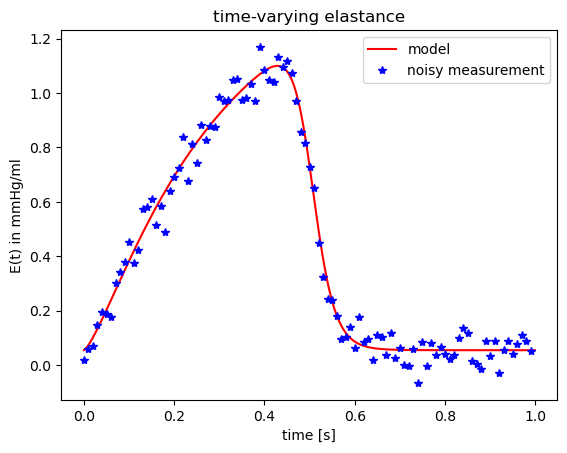

In [13]:
t_eval=torch.arange(0, NR_CYCLES*60/HR, 0.001)
NR_ALL_TIMESTEPS = len(t_eval)
result = elastance(t_eval, GROUND_TRUTH_PARAMETERS_VALUES) 

plt.plot(t_eval, result,'r-', label='model')
result += NOISE_STD*torch.randn(NR_ALL_TIMESTEPS)
random_selection = torch.randperm(NR_ALL_TIMESTEPS)[:NR_CONSIDERED_SAMPLES] #select 100 randomly permuted samples
evenly_spaced_selection = torch.arange(0, NR_ALL_TIMESTEPS)[::MAX_TIMESTEPS//NR_CONSIDERED_SAMPLES]
selection = evenly_spaced_selection
plt.plot(t_eval[evenly_spaced_selection], result[evenly_spaced_selection],'b*', label='noisy measurement')

plt.title('time-varying elastance')
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('E(t) in mmHg/ml')
plt.show()

# Define the model and the guide for SVI
We'll use lognormal distributions to estimate the parameters because they need to be positive.

We'll also include an inverse-gamma distribution to estimate the variance in the likelihood. 

The guide is a simple copy of the model with additional parameterization in the distributions as we do our optimization over these parameters.

In [14]:
nr_params = len(INTERESTING_PARAMETERS)

def pyro_model_SVI(t_eval, data):
    with pyro.plate("theta_plate", nr_params):
        theta = pyro.sample("theta", dist.LogNormal(1e-8*torch.ones((nr_params)), 1.0*torch.ones((nr_params))))
    sigma2 = pyro.sample("sigma2", dist.InverseGamma(2,2))
    
    with pyro.plate("data", len(data), subsample_size=NR_ALL_TIMESTEPS) as ind:
        return pyro.sample('obs', dist.Normal(elastance_reparameterized(t_eval[ind], theta), 
                                                        sigma2), obs=data[ind])
    
def custom_guide(t_eval, data):
    return 

## SVI inference

..........

Results for:  Diag
exponentiated mean =  tensor([1.0448, 0.0534, 0.0502, 0.0000, 0.0000, 0.0000, 0.0000],
       grad_fn=<CatBackward0>)
ground_truth =  tensor([ 1.0450,  0.0550,  1.6720,  0.3030,  0.5080,  1.3200, 21.9000])
relative error:  tensor([2.1355e-04, 2.8744e-02, 9.6996e-01, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00], grad_fn=<DivBackward0>)


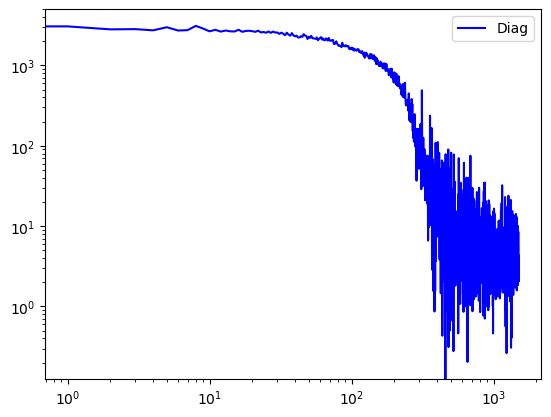

In [15]:
def do_SVI(guide):
    pyro.clear_param_store()
    optimizer = pyro.optim.Adam({"lr": 0.01}) 

    svi = pyro.infer.SVI(model=pyro_model_SVI, 
                        guide=guide, 
                        optim=optimizer, 
                        loss=pyro.infer.Trace_ELBO())

    losses = []
    for step in range(NR_EPOCHS):
        loss = svi.step(t_eval, result)
        losses.append(loss)
        if step % (NR_EPOCHS//10) == 0:
            print('.', end='')
    print("\n")
    return losses

SVI_types = {"Diag": [pyro.infer.autoguide.AutoDiagonalNormal(pyro_model_SVI), 'blue']}


for name, item in zip(SVI_types.keys(), SVI_types.values()):
    guide, color = item[0], item[1]
    losses = do_SVI(guide)

    plt.loglog(losses-np.min(losses), label=name, color=color)
    plt.legend()

    #Save the param_store because we have to clear it before each inference method
    results_SVI =  pyro.get_param_store()
    SVI_types[name].append(results_SVI)
    SVI_types[name].append(results_SVI.get_state())
    try:
        results_SVI_mean = torch.exp(guide._parameters['loc'])
    except:
        results_SVI_mean = torch.exp(results_SVI['loc'])

    if len(results_SVI_mean)<len(GROUND_TRUTH_PARAMETERS_VALUES.flatten()):
        results_SVI_mean = torch.concatenate((results_SVI_mean, torch.zeros(len(GROUND_TRUTH_PARAMETERS_VALUES.flatten())-len(results_SVI_mean))), axis=0)

    print("Results for: ", name)
    print("exponentiated mean = ", results_SVI_mean)
    print("ground_truth = ", GROUND_TRUTH_PARAMETERS_VALUES)
    
    relative_error = (GROUND_TRUTH_PARAMETERS_VALUES.flatten()-results_SVI_mean)/GROUND_TRUTH_PARAMETERS_VALUES.flatten() # AutoLaplaceApproximation.loc
    print("relative error: ", relative_error)

# MCMC model definition
Now we define the Markov Chain Monte Carlo model.
Notice that it is very similar to the main model of the SVI approach.


In [16]:
nr_params = 2 # usually equal to len(INTERESTING_PARAMETERS), but catches when we want to observe what happens to SVI for more params

def pyro_model_MCMC(t_eval, data):
    sigma2 = pyro.sample("sigma2", dist.InverseGamma(2,2))
    with pyro.plate("theta_plate", nr_params):
        theta = pyro.sample("theta", dist.LogNormal(torch.zeros((nr_params)), 1.0*torch.ones((nr_params))))

    with pyro.plate("data", len(t_eval)):
        return pyro.sample('obs', dist.Normal(elastance_reparameterized(t_eval, theta),
                                                        sigma2), obs=data)

# MCMC inference

In [17]:
nr_cpus = os.cpu_count() # add one more chain so that pyro does not try to parallelize
pyro.clear_param_store()

init_params, potential_fn, transforms, _ = initialize_model(
    pyro_model_MCMC,
    model_args=(t_eval[selection], result[selection]),
    num_chains=1, # 1<num_chains<nr_cpus+1 will attempt to parallelize which can take a while
    jit_compile=True,
    skip_jit_warnings=False,
    init_strategy=init_to_sample,
)
print("init params", init_params)
nuts_kernel = pyro.infer.NUTS(pyro_model_MCMC, adapt_step_size=True)
mcmc = pyro.infer.MCMC(nuts_kernel, 
                    num_samples=2500, 
                    warmup_steps=500,
                    num_chains=1, # 1<num_chains<nr_cpus+1 will attempt to parallelize which can take a while
                    initial_params=init_params,
                    transforms=transforms)

mcmc.run(t_eval[selection], result[selection]) #t_eval, result
mcmc.summary()

mean_estimated_values = (mcmc.get_samples()['theta'].mean(0))
print(mean_estimated_values)  
print("ground_truth = ", GROUND_TRUTH_PARAMETERS_VALUES)

if len(mean_estimated_values)<len(GROUND_TRUTH_PARAMETERS_VALUES.flatten()):
    mean_estimated_values = torch.concatenate((mean_estimated_values, torch.zeros(len(GROUND_TRUTH_PARAMETERS_VALUES.flatten())-len(mean_estimated_values))), axis=0)

relative_error = (GROUND_TRUTH_PARAMETERS_VALUES.flatten()-mean_estimated_values)/GROUND_TRUTH_PARAMETERS_VALUES.flatten()

print("relative error: ", relative_error)


init params {'sigma2': tensor(1.2189), 'theta': tensor([-0.1395,  0.9098])}


Sample: 100%|██████████| 3000/3000 [00:29, 102.50it/s, step size=5.00e-01, acc. prob=0.938]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
    sigma2      0.06      0.00      0.06      0.05      0.07   1771.54      1.00
  theta[0]      1.04      0.02      1.04      1.01      1.07   1350.59      1.00
  theta[1]      0.06      0.01      0.06      0.04      0.07   1329.95      1.00

Number of divergences: 0
tensor([1.0400, 0.0551])
ground_truth =  tensor([ 1.0450,  0.0550,  1.6720,  0.3030,  0.5080,  1.3200, 21.9000])
relative error:  tensor([ 0.0048, -0.0018,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000])


# Comparison of results
In this section we'll compare the results and their predictive capabilities.
We'll look at the distance between the retrieved parameters and the ground truth and their distributions.
The package we'll use for this purpose is called ```ChainConsumer```. It uses a number of samples retrieved from the posterior to do the visualization.
This means we need to draw some samples from the guide distribution in order for us to compare SVI and MCMC.

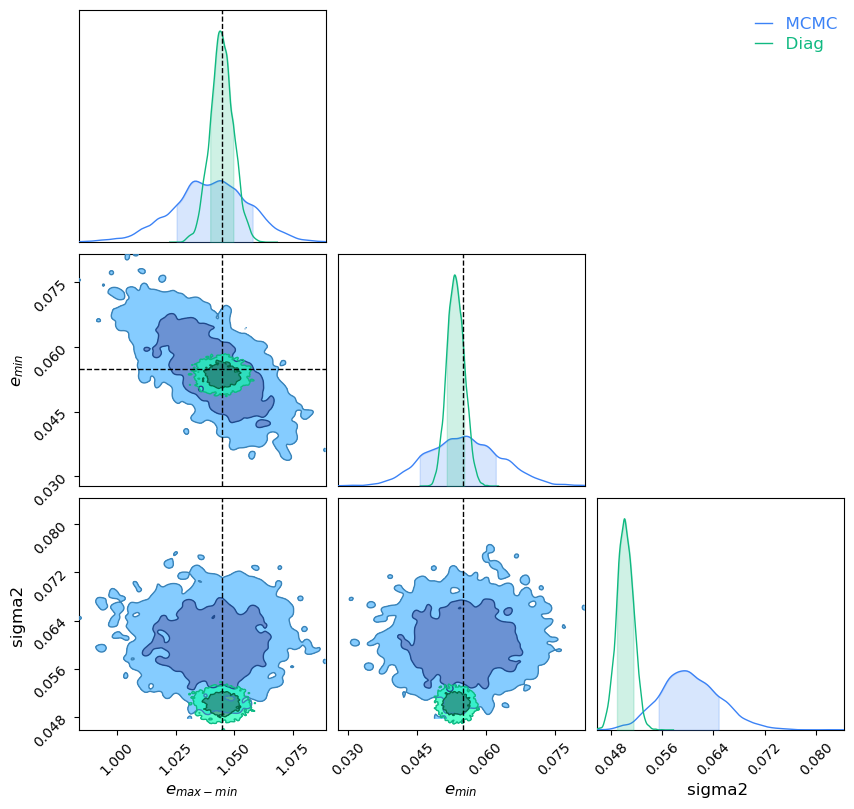

In [18]:
def samples_to_df(samples, param_list=INTERESTING_PARAMETERS):
    tmp_dict = {}
    for idx in range(samples['theta'].shape[1]):
        tmp_dict |= {param_list[idx]: samples['theta'][:, idx].flatten()}
    tmp_dict |= {r'sigma2': samples['sigma2'].flatten()}
    df = pd.DataFrame(tmp_dict)
    return df

C = ChainConsumer()
res = mcmc.get_samples()
C.add_chain(Chain(samples=samples_to_df(res), name="MCMC"))


pyro.clear_param_store()
for name, item in SVI_types.items():
    guide, color, param_store, state = item

    pyro.get_param_store().set_state(state)
    pred = pyro.infer.Predictive(guide, num_samples=5_000)(t_eval, result)
    pyro.clear_param_store()
    C.add_chain(Chain(samples=samples_to_df(pred), name=name))


C.add_truth(Truth(location=GROUND_TRUTH_PARAMETERS_REPARAM))

fig = C.plotter.plot()